In [1]:
import numpy as np
import pandas as pd
from scipy.io import mmread

## P2 (a)

In [2]:
# Load the matrix
# bcspwr09     (Power Networks)

A = mmread("/Users/lpwer/Documents/NetSIPhD/PHYS7332_NetData/HW2/power-bcspwr09/power-bcspwr09.mtx").tocoo()

# Save as edge list
with open("edges.csv", "w") as f:
    f.write("Source,Target\n")
    for i, j in zip(A.row, A.col):
        if i != j:  # optional: skip self-loops
            f.write(f"{i},{j}\n")

Modularity: 0.893

Modularity with resolution: 0.893

Number of Communities: 24

In [3]:
df = pd.read_csv('/Users/lpwer/Documents/NetSIPhD/PHYS7332_NetData/HW2/filtered_table.csv')

partition_MM = dict(zip(df['Id'], df['modularity_class']))

## P2 (b)

In [19]:
from graph_tool.all import *
import graph_tool.all as gt
import numpy as np
import json

In [18]:
df_edges = pd.read_csv('/Users/lpwer/Documents/NetSIPhD/PHYS7332_NetData/phys7332_fa25/HW2/edges.csv')
# x = pd.concat([df_edges[ucal], df_edges[vcal]])
# print(x)
labels = pd.Index(pd.unique(pd.concat([df_edges['Source'], df_edges['Target']])))
# print(labels)

labels_to_int = {lab: i for i, lab in enumerate(labels)}
# print(labels_to_int)

df_int = df_edges.copy()
df_int['Source'] = df_int['Source'].map(labels_to_int)
df_int['Target'] = df_int['Target'].map(labels_to_int)

print(df_int)

      Source  Target
0          0     966
1          1     967
2          2     968
3          3     969
4          4     970
...      ...     ...
4783     367     963
4784      42     257
4785     257     964
4786     124     965
4787     575      52

[4788 rows x 2 columns]


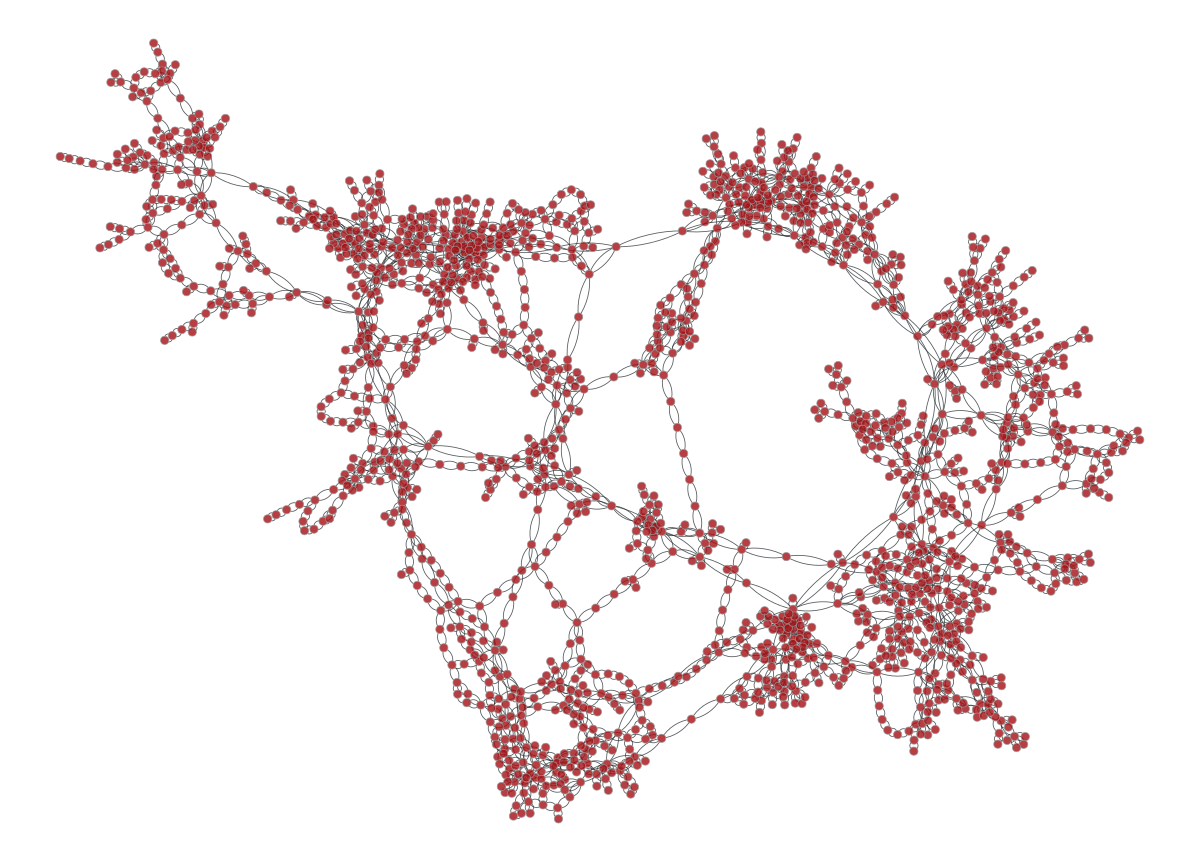

<VertexPropertyMap object with value type 'vector<double>', for Graph 0x15589d450, at 0x155240440>

In [21]:
g = gt.Graph(directed=False)
g.add_vertex(len(labels))
g.add_edge_list(df_int[['Source', 'Target']].itertuples(index=False, name=None))

gt.graph_draw(g)